Running simulations: 100%|████████████████████████████████████████████████████████████████████████| 10/10 [00:10<00:00,  1.06s/it]


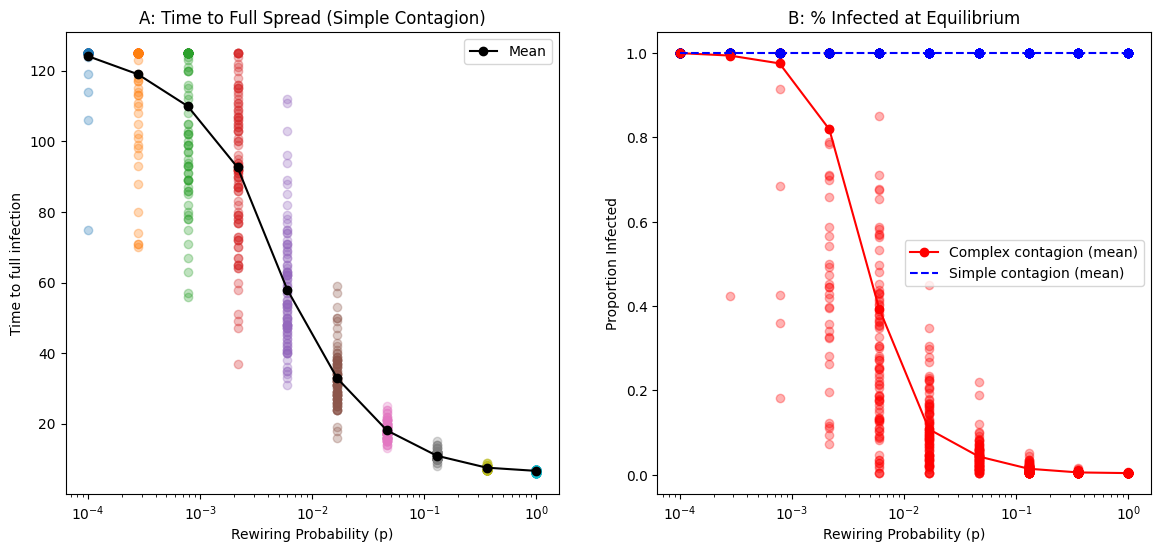

In [9]:
#!pip install networkx
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
import tqdm

# パラメータ
N = 500
k = 4  # 各ノードの初期近傍数（偶数にする）
tau = 1.0  # 感染確率
rewiring_probs = np.logspace(-4, 0, 10)  # 10個のp（対数スケール）
num_runs = 100

# 結果格納
simple_times = {p: [] for p in rewiring_probs}
complex_percent = {p: [] for p in rewiring_probs}

# 感染拡散関数
def run_simulation(G, complex_contagion=False):
    infected = set()
    nodes = list(G.nodes)
    seed = random.choice(nodes)
    neighbor = random.choice(list(G.neighbors(seed)))
    infected.update([seed, neighbor])

    time = 0
    while True:
        new_infected = set()
        for node in G.nodes:
            if node not in infected:
                infected_neighbors = [n for n in G.neighbors(node) if n in infected]
                if complex_contagion:
                    if len(infected_neighbors) >= 2 and random.random() < tau:
                        new_infected.add(node)
                else:
                    if len(infected_neighbors) >= 1 and random.random() < tau:
                        new_infected.add(node)
        if not new_infected:
            break
        infected.update(new_infected)
        time += 1
        if len(infected) == N:
            break
    return time, len(infected) / N

# シミュレーション
for p in tqdm.tqdm(rewiring_probs, desc="Running simulations"):
    for _ in range(num_runs):
        G = nx.watts_strogatz_graph(N, k, p)
        
        # Simple contagion
        t_simple, _ = run_simulation(G, complex_contagion=False)
        simple_times[p].append(t_simple)

        # Complex contagion
        _, pct_complex = run_simulation(G, complex_contagion=True)
        complex_percent[p].append(pct_complex)

# グラフ作成
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# A: Simple contagion spread time
axs[0].set_title("A: Time to Full Spread (Simple Contagion)")
for p in rewiring_probs:
    axs[0].plot([p] * num_runs, simple_times[p], 'o', alpha=0.3)
axs[0].plot(rewiring_probs, [np.mean(simple_times[p]) for p in rewiring_probs], '-o', color='black', label='Mean')
axs[0].set_xscale('log')
axs[0].set_xlabel("Rewiring Probability (p)")
axs[0].set_ylabel("Time to full infection")
axs[0].legend()

# B: Percent Infected at Equilibrium（色分けあり）
axs[1].set_title("B: % Infected at Equilibrium")

# 各pに対して、simpleとcomplexの結果をプロット
for p in rewiring_probs:
    # 複雑感染の各試行点（赤）
    axs[1].plot([p] * num_runs, complex_percent[p], 'o', alpha=0.3, color='red', label='_nolegend_')
    # 単純感染は常に1.0なので、水平線の代わりに点を打っておく（青）
    axs[1].plot([p] * num_runs, [1.0] * num_runs, 'o', alpha=0.1, color='blue', label='_nolegend_')

# 平均値を線で表示（色分け）
axs[1].plot(rewiring_probs, [np.mean(complex_percent[p]) for p in rewiring_probs],
            '-o', color='red', label='Complex contagion (mean)')
axs[1].plot(rewiring_probs, [1.0] * len(rewiring_probs),
            '--', color='blue', label='Simple contagion (mean)')

axs[1].set_xscale('log')
axs[1].set_xlabel("Rewiring Probability (p)")
axs[1].set_ylabel("Proportion Infected")
axs[1].legend()


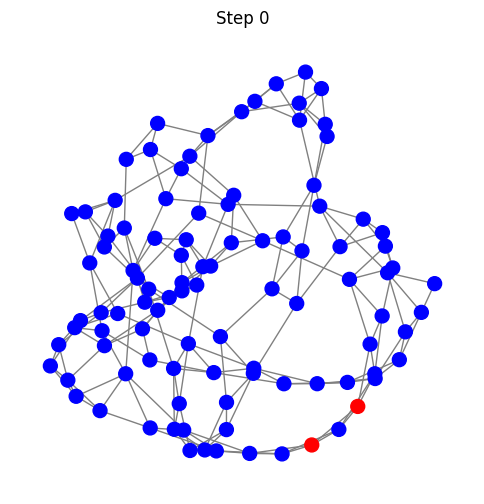

In [32]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import rc
from IPython.display import HTML
import random

# パラメータ設定
N = 100  # ノード数（小さめにして描画が速いように）
k = 4
p = 0.1
tau = 1.0  # 感染確率

# ネットワーク作成
G = nx.watts_strogatz_graph(N, k, p)
pos = nx.spring_layout(G, seed=42)  # 固定レイアウト

# 初期化
states = {n: 'S' for n in G.nodes}  # 'S' = susceptible, 'I' = infected
history = []  # 各ステップの感染状態

# 感染者2人
seed = random.choice(list(G.nodes))
neighbor = random.choice(list(G.neighbors(seed)))
states[seed] = 'I'
states[neighbor] = 'I'

# 初期状態記録
history.append(states.copy())

# 感染シミュレーション
while True:
    new_infected = []
    for node in G.nodes:
        if states[node] == 'S':
            infected_neighbors = [n for n in G.neighbors(node) if states[n] == 'I']
            if len(infected_neighbors) > 0 and random.random() < tau:
                new_infected.append(node)
    if not new_infected:
        break
    for node in new_infected:
        states[node] = 'I'
    history.append(states.copy())

# 色のマップ：S → blue, I → red
def get_node_colors(state_dict):
    return ['red' if state_dict[n] == 'I' else 'blue' for n in G.nodes]

# アニメーション描画関数
fig, ax = plt.subplots(figsize=(6, 6))

def update(i):
    ax.clear()
    nx.draw(G, pos=pos, node_color=get_node_colors(history[i]), 
            with_labels=False, node_size=100, edge_color='gray')
    ax.set_title(f"Step {i}")

ani = animation.FuncAnimation(fig, update, frames=len(history), interval=500, repeat=False)

# HTMLとして表示
rc('animation', html='html5')
#HTML(ani.to_jshtml())
